# *CS6140 Project - Machine Learning* <br> **Predict Calorie Expenditure** 
### **Stacked Ridge Ensemble**  <br> Kaggle Playground Series S5E5

**Authors:** 
- Keith Fernandes   - fernandes.kei@northeastern.edu
- Shreyans Jain     - jain.shreyans@northeastern.edu

This notebook implements the calorie-expenditure regression pipeline described in the project proposal: diverse base learners (gradient boosting, tree ensembles, neural
networks, AutoML) evaluated under identical 5-fold cross-validation and combined with a Ridge-regression meta-learner.

**Primary Metric:**
- **RMSLE** (equivalent to RMSE on `log1p(y)`). 
- Calorie-scale **RMSE** is reported as a secondary metric for interpretability.

All generated artifacts (figures, tables, OOF/test predictions, submissions, model
caches) are written to `Results/` relative to the repo root, ready to cite from the
final report.

## **Environment**

Runs locally by default; the same file can be uploaded to Colab without modification.
Uncomment the pip cell below on a fresh environment.

**Required:** `numpy`, `pandas`, `scikit-learn`, `xgboost`, `lightgbm`, `catboost`, `ydf`,
`tensorflow`/`keras>=3`, `optuna`, `joblib`, `matplotlib`, `seaborn`, `requests`.   <br>
**Optional:** (gated by `CFG.run_autogluon`): `autogluon.tabular`.

In [118]:
!pip install numpy pandas scikit-learn xgboost lightgbm catboost ydf tensorflow optuna joblib matplotlib seaborn requests
!pip install autogluon.tabular   # optional, heavy (~500 MB)

## **Dataset setup**
If you have not cloned the GitHub repo and just using the notebook then download the dataset zip from [here](https://drive.google.com/file/d/1pfQ8wWWYp1Z75_ZZw7qJA93ZaZXjzS4p/view?usp=sharing) and place it in `Datasets/` as `data.zip`.

Otherwise, the dataset will be in `Datasets/` directory

The notebook will only extract files from the local `Datasets/` folder and will not download data automatically.

Expected CSV files after extraction: `train.csv`, `test.csv`, `calories.csv`.

In [119]:
from pathlib import Path
import contextlib
import io
import json
import os
import shutil
import sys
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

In [120]:
class CFG:
    # Dataset zip containing train.csv, test.csv, calories.csv.
    # Place this zip file inside Datasets/ before running the notebook.

    data_zip_name = "dataset-KF-SJ-CS6140.zip"
    required_csvs = ("train.csv", "test.csv", "calories.csv")

    target = "Calories"
    seed = 42
    n_folds = 5

    # Tuning / toggles
    run_optuna = True
    n_optuna_trials = 250
    run_autogluon = True
    autogluon_time_limit = 600  # seconds per fold
    nn_seeds = 3
    run_ablation = True         # run engineered-features ablation (LightGBM, ~5 min)
    force_retrain = False       # set True to bust caches and rerun all base models

    # Google Drive persistence (Colab only). When True on Colab, DATA_DIR and
    # RESULTS_DIR are rooted at drive_root on mounted Drive so downloads, model caches,
    # figures, tables, OOF preds, and submissions all persist across runtime restarts.
    # Off Colab this flag is ignored and paths stay local to the repo.
    use_drive = True
    drive_root = "/content/drive/MyDrive/Predict_Calorie_Expenditure"

    # GPU detection:
    # - "auto"  : detect CUDA (via nvidia-smi) and Apple Silicon MPS separately.
    # - "yes"   : force CUDA on (fails loudly if absent). MPS cannot be forced.
    # - "no"    : pin every library to CPU.
    # CUDA gates XGBoost + CatBoost (the only base learners with a CUDA path here).
    # MPS only affects Keras/TensorFlow - it uses Metal automatically when
    # `tensorflow-metal` is installed on Apple Silicon; XGBoost, CatBoost, LightGBM, and
    # YDF have no MPS backend, so they stay on CPU regardless.
    # LightGBM GPU stays off: the default pip wheel is CPU-only - set
    # lgbm_params["device"] = "gpu" manually with a GPU-enabled build if you need it.
    use_gpu = "auto"

In [121]:
def _is_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


IS_COLAB = _is_colab()

if CFG.use_drive and IS_COLAB:
    print(f"Mounting Google Drive — repo root will be {CFG.drive_root}")
    from google.colab import drive as _gdrive
    _gdrive.mount("/content/drive")
    REPO_ROOT = Path(CFG.drive_root).expanduser()
    REPO_ROOT.mkdir(parents=True, exist_ok=True)
elif CFG.use_drive and not IS_COLAB:
    print("CFG.use_drive=True but not running on Colab — falling back to local paths.")
    NB_DIR = Path.cwd()
    REPO_ROOT = NB_DIR.parent if (NB_DIR.parent / "Datasets").exists() else NB_DIR
else:
    NB_DIR = Path.cwd()
    REPO_ROOT = NB_DIR.parent if (NB_DIR.parent / "Datasets").exists() else NB_DIR

DATA_DIR = REPO_ROOT / "Datasets"
RESULTS_DIR = REPO_ROOT / "Results"
FIG_DIR = RESULTS_DIR / "figures"
TAB_DIR = RESULTS_DIR / "tables"
SUB_DIR = RESULTS_DIR / "submissions"
OOF_DIR = RESULTS_DIR / "oof_preds"
MODEL_DIR = RESULTS_DIR / "models"

for d in (DATA_DIR, RESULTS_DIR, FIG_DIR, TAB_DIR, SUB_DIR, OOF_DIR, MODEL_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {REPO_ROOT}")
print(f"Data dir:  {DATA_DIR}")
print(f"Results:   {RESULTS_DIR}")

Mounting Google Drive — repo root will be /content/drive/MyDrive/Predict_Calorie_Expenditure
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Repo root: /content/drive/MyDrive/Predict_Calorie_Expenditure
Data dir:  /content/drive/MyDrive/Predict_Calorie_Expenditure/Datasets
Results:   /content/drive/MyDrive/Predict_Calorie_Expenditure/Results


In [122]:
def _detect_cuda() -> bool:
    import subprocess
    try:
        subprocess.check_output(["nvidia-smi"], stderr=subprocess.DEVNULL, timeout=5)
        return True
    except Exception:
        return False


def _detect_apple_silicon() -> bool:
    import platform
    return platform.system() == "Darwin" and platform.machine() == "arm64"


if CFG.use_gpu == "yes":
    HAS_CUDA, HAS_MPS = True, False
elif CFG.use_gpu == "no":
    HAS_CUDA, HAS_MPS = False, False
else:
    HAS_CUDA = _detect_cuda()
    HAS_MPS = _detect_apple_silicon()

# XGBoost + CatBoost only have a CUDA path — MPS does not apply to them.
HAS_GPU = HAS_CUDA

print(f"GPU detection — CUDA: {HAS_CUDA}  MPS (Keras/TF only): {HAS_MPS}")
if HAS_MPS and not HAS_CUDA:
    print("  Keras will auto-use MPS via tensorflow-metal if installed "
          "(pip install tensorflow-metal).")
if not HAS_CUDA:
    print("  XGBoost + CatBoost will run on CPU (no CUDA backend for MPS).")

GPU detection — CUDA: True  MPS (Keras/TF only): False


In [123]:
import zipfile


def _extract_zip(zip_path: Path, target_dir: Path, required: tuple[str, ...]) -> None:
    print(f"Extracting {zip_path.name} into {target_dir} ...")
    with zipfile.ZipFile(zip_path) as zf:
        members = zf.namelist()
        for req in required:
            matches = [m for m in members if Path(m).name == req]
            if not matches:
                raise RuntimeError(f"{req} not found in {zip_path.name}; members: {members}")
            with zf.open(matches[0]) as src, open(target_dir / req, "wb") as dst:
                shutil.copyfileobj(src, dst)
    print(f"  extracted: {', '.join(required)}")


def ensure_datasets() -> None:
    missing = [c for c in CFG.required_csvs if not (DATA_DIR / c).exists()]
    if not missing:
        return

    zip_path = DATA_DIR / CFG.data_zip_name
    if not zip_path.exists():
        raise RuntimeError(
            "Missing dataset files. Download the dataset zip from "
            "https://drive.google.com/file/d/1pfQ8wWWYp1Z75_ZZw7qJA93ZaZXjzS4p/view?usp=sharing and place it at "
            f"{zip_path}, then rerun."
        )

    _extract_zip(zip_path, DATA_DIR, CFG.required_csvs)


ensure_datasets()

## **Data Loading and Preprocessing**

- Binary-encode `Sex` as `male → 0`, `female → 1` (applied identically to the external
  `calories.csv`, where the column is `Gender`).
- Log-transform the target with `log1p`; training therefore minimizes RMSE on
  `log1p(y)`, which is exactly RMSLE. Predictions are back-transformed with `expm1`
  before submission.

In [124]:
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

train = pd.read_csv(DATA_DIR / "train.csv", index_col="id")
test = pd.read_csv(DATA_DIR / "test.csv", index_col="id")
original = pd.read_csv(DATA_DIR / "calories.csv", index_col="User_ID")
original = original.rename(columns={"Gender": "Sex"})

for df in (train, test, original):
    df["Sex"] = df["Sex"].map({"male": 0, "female": 1}).astype("int8")

X = train.drop(columns=[CFG.target])
y = np.log1p(train[CFG.target])
X_test = test.copy()

X_original = original.drop(columns=[CFG.target])
y_original = np.log1p(original[CFG.target])

print(f"train: {X.shape}  test: {X_test.shape}  original: {X_original.shape}")

train: (750000, 7)  test: (250000, 7)  original: (15000, 7)


## **Data Quality**

Per-feature missing-value and IQR-based outlier counts, saved to
`Results/tables/data_quality.csv`. Distribution histograms saved to
`Results/figures/distributions.png`.

In [125]:
def iqr_outliers(s: pd.Series, k: float = 1.5) -> int:
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return int(((s < lo) | (s > hi)).sum())


quality_rows = []
for col in X.columns:
    quality_rows.append(
        {
            "feature": col,
            "missing": int(X[col].isnull().sum()),
            "outliers_iqr": iqr_outliers(X[col])
            if pd.api.types.is_numeric_dtype(X[col])
            else None,
            "min": X[col].min(),
            "max": X[col].max(),
            "mean": X[col].mean(),
            "std": X[col].std(),
        }
    )
quality_df = pd.DataFrame(quality_rows)
quality_df.to_csv(TAB_DIR / "data_quality.csv", index=False)
print(quality_df.to_string(index=False))

   feature  missing  outliers_iqr   min   max       mean       std
       Sex        0             0   0.0   1.0   0.500961  0.499999
       Age        0             0  20.0  79.0  41.420404 15.175049
    Height        0            14 126.0 222.0 174.697685 12.824496
    Weight        0             9  36.0 132.0  75.145668 13.982704
  Duration        0             0   1.0  30.0  15.421015  8.354095
Heart_Rate        0            36  67.0 128.0  95.483995  9.449845
 Body_Temp        0         14919  37.1  41.5  40.036253  0.779875


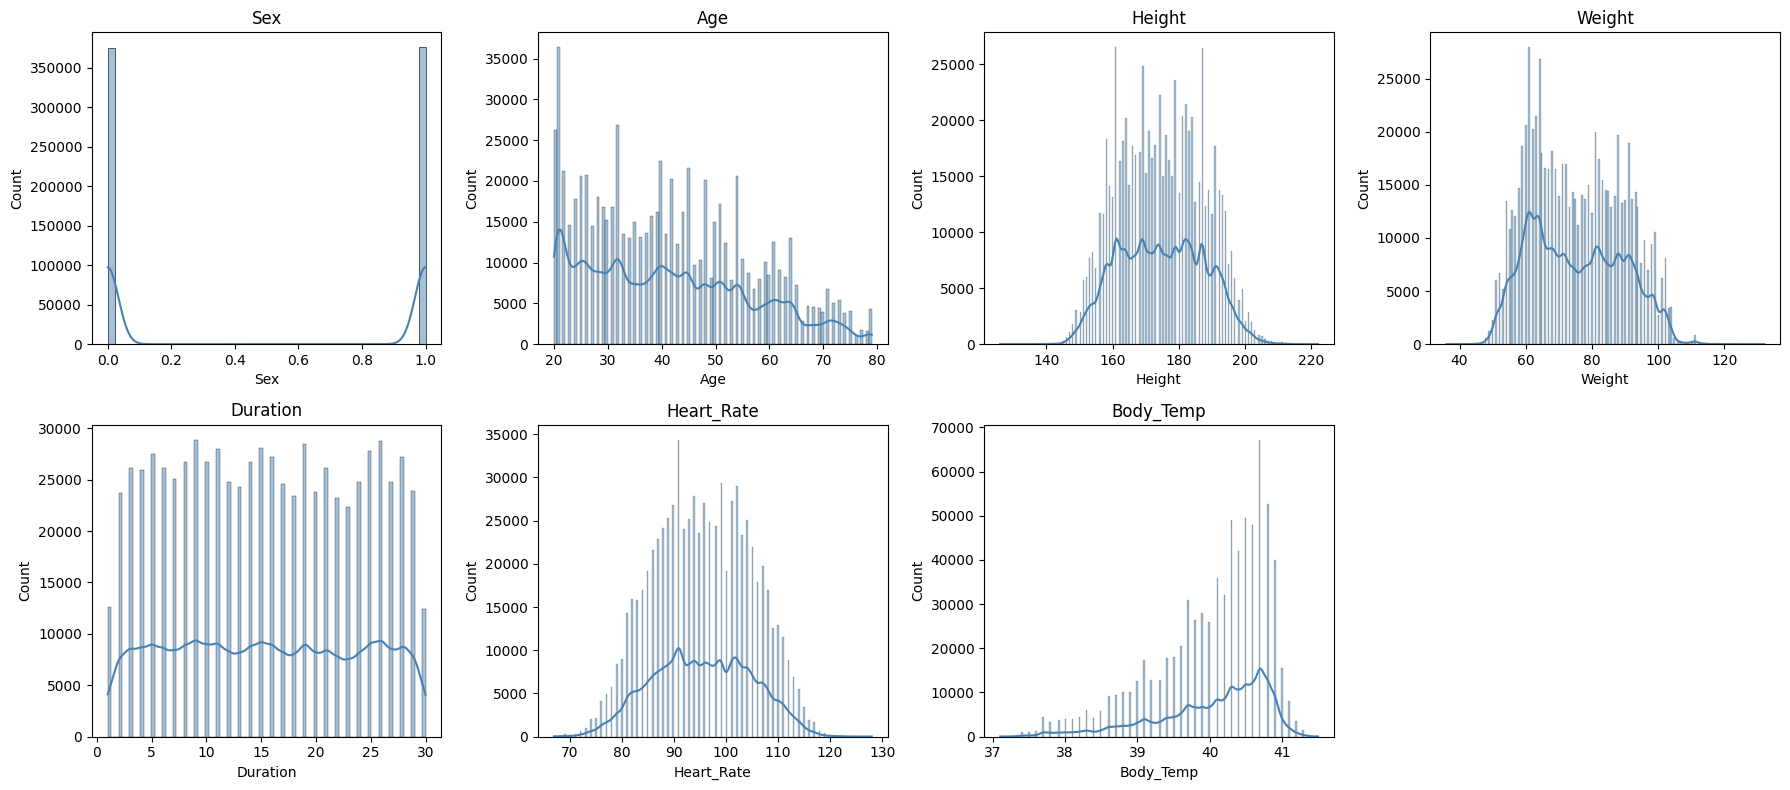

In [126]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, X.columns):
    sns.histplot(X[col], ax=ax, kde=True, color="steelblue")
    ax.set_title(col)
for ax in axes.flat[len(X.columns):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## **Feature Engineering**

Two engineered features from the proposal:
- **BMI** = `Weight / (Height/100)²` - a standard body-composition proxy.
- **Duration × Heart_Rate** — an exercise-intensity proxy.

Applied consistently to `X`, `X_test`, and `X_original` so the external dataset and
every model (trees + NN) see the same feature space.

In [127]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["BMI"] = df["Weight"] / (df["Height"] / 100.0) ** 2
    df["Duration_x_HR"] = df["Duration"] * df["Heart_Rate"]
    return df


X = add_features(X)
X_test = add_features(X_test)
X_original = add_features(X_original)
print(X.columns.tolist())

['Sex', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'BMI', 'Duration_x_HR']


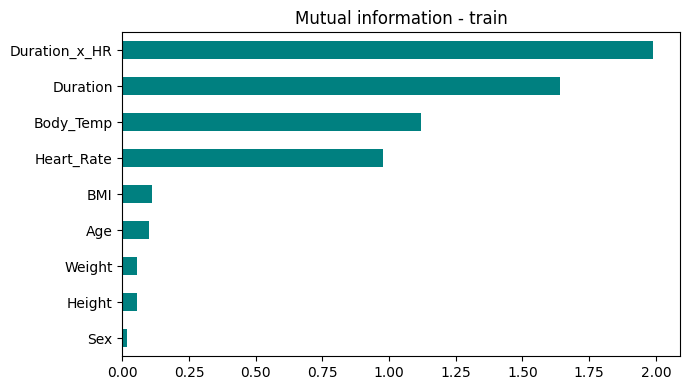

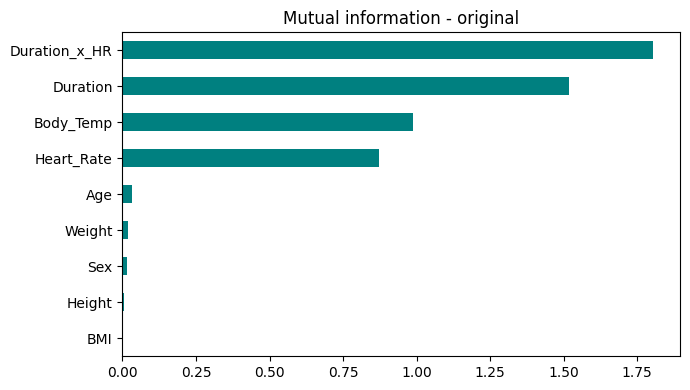

In [128]:
from sklearn.feature_selection import mutual_info_regression


def mi_table(X_: pd.DataFrame, y_: pd.Series, name: str) -> pd.Series:
    mi = mutual_info_regression(X_, y_, random_state=CFG.seed)
    s = (
        pd.Series(mi, index=X_.columns, name="Mutual Information")
        .sort_values(ascending=False)
    )
    ax = s.plot(kind="barh", figsize=(7, 4), color="teal")
    ax.invert_yaxis()
    ax.set_title(f"Mutual information - {name}")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"mutual_info_{name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    s.to_frame().to_csv(TAB_DIR / f"mutual_info_{name}.csv")
    return s


_ = mi_table(X, y, "train")
_ = mi_table(X_original, y_original, "original")

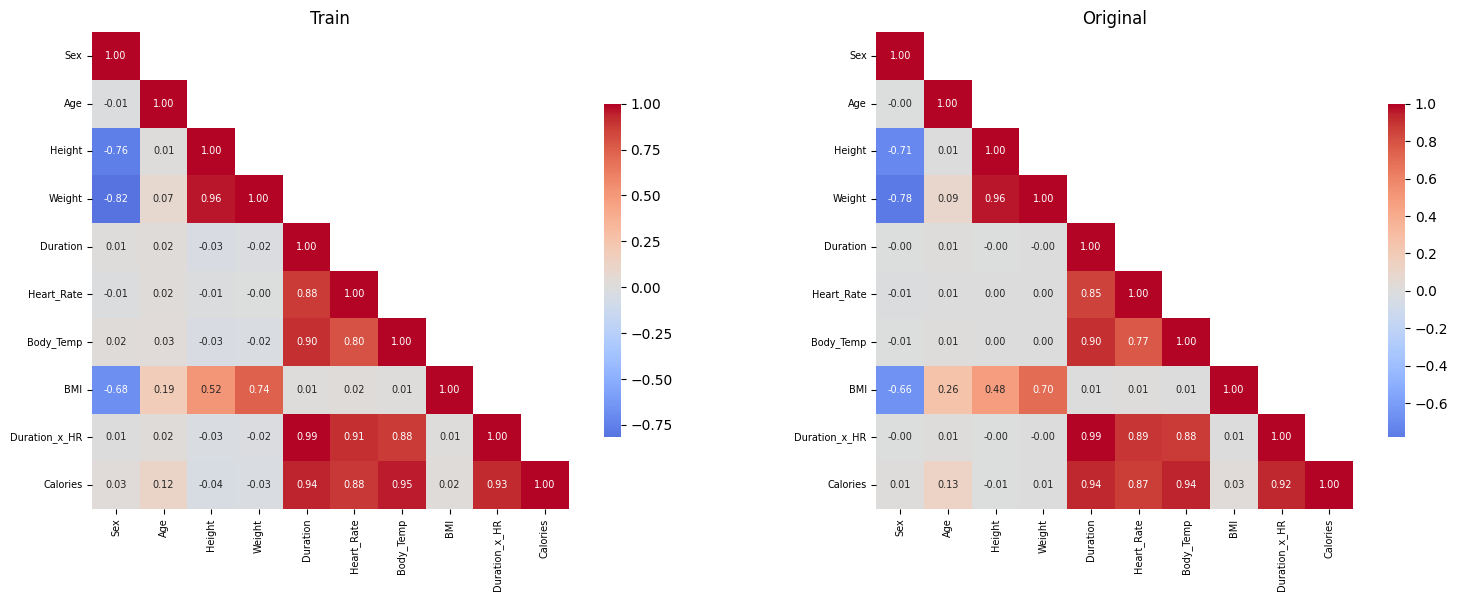

In [129]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (df, name) in zip(
    axes,
    [
        (X.assign(**{CFG.target: y}), "Train"),
        (X_original.assign(**{CFG.target: y_original}), "Original"),
    ],
):
    corr = df.corr(numeric_only=True)
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        mask=mask,
        square=True,
        cmap="coolwarm",
        cbar_kws={"shrink": 0.7},
        annot_kws={"size": 7},
        center=0,
        ax=ax,
    )
    ax.set_title(name)
    ax.tick_params(axis="both", labelsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR / "corr_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

## Shared helpers

- `evaluate()` - reports RMSLE (log-scale RMSE) and calorie-scale RMSE.
- `train_cv()` - replaces `koolbox.Trainer` and the per-model cache blocks. Runs k-fold
  CV, optionally concatenates the external dataset to each training fold, caches
  `{fold_scores, oof_preds, test_preds}` to `Results/models/{name}.pkl`.
- `register_result()` - shared sink that stores per-model arrays into the global dicts
  and writes OOF / test predictions to `Results/oof_preds/<name>_*.parquet`.

In [130]:
def evaluate(y_true_log: np.ndarray, y_pred_log: np.ndarray) -> dict:
    rmsle = root_mean_squared_error(y_true_log, y_pred_log)
    rmse_cal = root_mean_squared_error(np.expm1(y_true_log), np.expm1(y_pred_log))
    return {"RMSLE": rmsle, "RMSE_cal": rmse_cal}


def train_cv(
    model_factory,
    X: pd.DataFrame,
    y: pd.Series,
    X_test: pd.DataFrame,
    *,
    cv,
    name: str,
    cache_dir: Path,
    extra_X: pd.DataFrame | None = None,
    extra_y: pd.Series | None = None,
    fit_kwargs: dict | None = None,
    requires_eval_set: bool = False,
    force: bool = False,
    verbose: bool = True,
) -> dict:
    fit_kwargs = fit_kwargs or {}
    cache_path = Path(cache_dir) / f"{name}.pkl"
    if cache_path.exists() and not force:
        if verbose:
            print(f"[{name}] loading from cache: {cache_path}")
        return joblib.load(cache_path)

    oof = np.zeros(len(X))
    test_fold_preds = []
    fold_scores = []
    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y)):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]
        if extra_X is not None and extra_y is not None:
            X_tr = pd.concat([X_tr, extra_X], axis=0)
            y_tr = pd.concat([y_tr, extra_y], axis=0)

        model = model_factory()
        kw = dict(fit_kwargs)
        if requires_eval_set:
            kw["eval_set"] = [(X_va, y_va)]
        model.fit(X_tr, y_tr, **kw)

        pred_va = np.asarray(model.predict(X_va)).squeeze()
        pred_te = np.asarray(model.predict(X_test)).squeeze()
        oof[va_idx] = pred_va
        test_fold_preds.append(pred_te)
        score = root_mean_squared_error(y_va, pred_va)
        fold_scores.append(score)
        if verbose:
            print(f"[{name}] fold {fold}: RMSLE = {score:.6f}")

    result = {
        "fold_scores": fold_scores,
        "oof_preds": oof,
        "test_preds": np.mean(test_fold_preds, axis=0),
        "eval": evaluate(y.values, oof),
    }
    if verbose:
        print(
            f"[{name}] overall RMSLE: {result['eval']['RMSLE']:.6f} "
            f"| RMSE(cal): {result['eval']['RMSE_cal']:.4f}"
        )
    joblib.dump(result, cache_path)
    return result


cv = KFold(n_splits=CFG.n_folds, shuffle=True, random_state=CFG.seed)
scores: dict[str, list[float]] = {}
oof_preds: dict[str, np.ndarray] = {}
test_preds: dict[str, np.ndarray] = {}


def register_result(name: str, res: dict) -> None:
    scores[name] = res["fold_scores"]
    oof_preds[name] = res["oof_preds"]
    test_preds[name] = res["test_preds"]
    pd.DataFrame({"oof": res["oof_preds"]}).to_parquet(OOF_DIR / f"{name}_oof.parquet")
    pd.DataFrame({"test": res["test_preds"]}).to_parquet(OOF_DIR / f"{name}_test.parquet")

## **Training Base Models**

Gradient-boosting hyperparameters come from prior Optuna runs and are fixed here. <br> 
Tree ensembles use sensible defaults. Ridge meta-learner is tuned below. <br> 
All models use the same 5-fold `KFold(shuffle=True, random_state=42)` with the external `calories.csv` appended to each training fold.

In [131]:
histgb_params = dict(
    l2_regularization=10.412017522533768,
    learning_rate=0.011702680619474444,
    max_depth=59,
    max_features=0.30616140080552673,
    max_iter=4454,
    max_leaf_nodes=385,
    min_samples_leaf=50,
    random_state=CFG.seed,
)

lgbm_params = dict(
    boosting_type="gbdt",
    colsample_bytree=0.8213924491907012,
    learning_rate=0.059976685297931195,
    min_child_samples=10,
    min_child_weight=0.5425237767880097,
    n_estimators=50000,
    n_jobs=-1,
    num_leaves=89,
    random_state=CFG.seed,
    reg_alpha=2.0325709613371545,
    reg_lambda=87.27971117911044,
    subsample=0.6452823633939004,
    verbose=-1,
)

lgbm_goss_params = dict(
    boosting_type="goss",
    colsample_bytree=0.9068724002629094,
    learning_rate=0.06459027654473874,
    min_child_samples=39,
    min_child_weight=0.5337673729810578,
    n_estimators=50000,
    n_jobs=-1,
    num_leaves=13,
    random_state=CFG.seed,
    reg_alpha=1.603969498256519,
    reg_lambda=10.806488455621444,
    subsample=0.5966412222358356,
    verbose=-1,
)

xgb_params = dict(
    colsample_bylevel=0.8606487417581108,
    colsample_bynode=0.9410596660335436,
    colsample_bytree=0.9407540036296737,
    early_stopping_rounds=100,
    eval_metric="rmse",
    gamma=0.023260595738991977,
    learning_rate=0.03669372905801298,
    max_depth=11,
    max_leaves=51,
    min_child_weight=96,
    n_estimators=50000,
    n_jobs=-1,
    random_state=CFG.seed,
    reg_alpha=2.953205886504917,
    reg_lambda=67.64147033446291,
    subsample=0.6973241930754311,
    verbosity=0,
    tree_method="hist",
    device="cuda" if HAS_GPU else "cpu",
)

cb_params = dict(
    border_count=88,
    depth=8,
    eval_metric="RMSE",
    iterations=50000,
    l2_leaf_reg=6.065104074215131,
    learning_rate=0.030946464122148992,
    min_child_samples=138,
    random_state=CFG.seed,
    random_strength=0.035251008593976785,
    verbose=False,
    task_type="GPU" if HAS_GPU else "CPU",
)

# CatBoost's colsample_bylevel (internally `rsm`) is CPU-only for non-pairwise tasks —
# adding it to GPU params triggers: "rsm on GPU is supported for pairwise modes only".
if not HAS_GPU:
    cb_params["colsample_bylevel"] = 0.7903437608890396

rf_params = dict(
    n_estimators=300,
    n_jobs=-1,
    max_depth=None,
    min_samples_leaf=5,
    random_state=CFG.seed,
)

et_params = dict(
    n_estimators=300,
    n_jobs=-1,
    max_depth=None,
    min_samples_leaf=5,
    random_state=CFG.seed,
)

ydf_params = dict(num_trees=1000, max_depth=8)

### **HistGradientBoosting**

In [132]:
from sklearn.ensemble import HistGradientBoostingRegressor

name = "HistGB"
res = train_cv(
    lambda: HistGradientBoostingRegressor(**histgb_params),
    X, y, X_test,
    cv=cv,
    name=name,
    cache_dir=MODEL_DIR,
    extra_X=X_original,
    extra_y=y_original,
    force=CFG.force_retrain,
)
register_result(name, res)

[HistGB] loading from cache: /content/drive/MyDrive/Predict_Calorie_Expenditure/Results/models/HistGB.pkl


### **LightGBM (gbdt)**

In [133]:
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

name = "LightGBM (gbdt)"
res = train_cv(
    lambda: LGBMRegressor(**lgbm_params),
    X, y, X_test,
    cv=cv,
    name=name,
    cache_dir=MODEL_DIR,
    extra_X=X_original,
    extra_y=y_original,
    requires_eval_set=True,
    fit_kwargs={
        "eval_metric": "rmse",
        "callbacks": [log_evaluation(period=1000), early_stopping(stopping_rounds=100)],
    },
    force=CFG.force_retrain,
)
register_result(name, res)

[LightGBM (gbdt)] loading from cache: /content/drive/MyDrive/Predict_Calorie_Expenditure/Results/models/LightGBM (gbdt).pkl


### **LightGBM (goss)**

In [134]:
name = "LightGBM (goss)"
res = train_cv(
    lambda: LGBMRegressor(**lgbm_goss_params),
    X, y, X_test,
    cv=cv,
    name=name,
    cache_dir=MODEL_DIR,
    extra_X=X_original,
    extra_y=y_original,
    requires_eval_set=True,
    fit_kwargs={
        "eval_metric": "rmse",
        "callbacks": [log_evaluation(period=1000), early_stopping(stopping_rounds=100)],
    },
    force=CFG.force_retrain,
)
register_result(name, res)

[LightGBM (goss)] loading from cache: /content/drive/MyDrive/Predict_Calorie_Expenditure/Results/models/LightGBM (goss).pkl


### **XGBoost**

In [135]:
from xgboost import XGBRegressor

name = "XGBoost"
res = train_cv(
    lambda: XGBRegressor(**xgb_params),
    X, y, X_test,
    cv=cv,
    name=name,
    cache_dir=MODEL_DIR,
    extra_X=X_original,
    extra_y=y_original,
    requires_eval_set=True,
    fit_kwargs={"verbose": 1000},
    force=CFG.force_retrain,
)
register_result(name, res)

[XGBoost] loading from cache: /content/drive/MyDrive/Predict_Calorie_Expenditure/Results/models/XGBoost.pkl


### **CatBoost**

In [136]:
from catboost import CatBoostRegressor

name = "CatBoost"
res = train_cv(
    lambda: CatBoostRegressor(**cb_params),
    X, y, X_test,
    cv=cv,
    name=name,
    cache_dir=MODEL_DIR,
    extra_X=X_original,
    extra_y=y_original,
    requires_eval_set=True,
    fit_kwargs={
        "verbose": 1000,
        "early_stopping_rounds": 100,
        "use_best_model": True,
    },
    force=CFG.force_retrain,
)
register_result(name, res)
shutil.rmtree("catboost_info", ignore_errors=True)

[CatBoost] loading from cache: /content/drive/MyDrive/Predict_Calorie_Expenditure/Results/models/CatBoost.pkl


### **Random Forest**

In [137]:
from sklearn.ensemble import RandomForestRegressor

name = "RandomForest"
res = train_cv(
    lambda: RandomForestRegressor(**rf_params),
    X, y, X_test,
    cv=cv,
    name=name,
    cache_dir=MODEL_DIR,
    extra_X=X_original,
    extra_y=y_original,
    force=CFG.force_retrain,
)
register_result(name, res)

[RandomForest] loading from cache: /content/drive/MyDrive/Predict_Calorie_Expenditure/Results/models/RandomForest.pkl


### **Extra Trees**

In [138]:
from sklearn.ensemble import ExtraTreesRegressor

name = "ExtraTrees"
res = train_cv(
    lambda: ExtraTreesRegressor(**et_params),
    X, y, X_test,
    cv=cv,
    name=name,
    cache_dir=MODEL_DIR,
    extra_X=X_original,
    extra_y=y_original,
    force=CFG.force_retrain,
)
register_result(name, res)

[ExtraTrees] loading from cache: /content/drive/MyDrive/Predict_Calorie_Expenditure/Results/models/ExtraTrees.pkl


### **Yggdrasil (YDF)**

YDF's native pandas API is wrapped in a small sklearn-compatible shim so it plugs into
`train_cv` without the heavy custom class from the previous version.

In [139]:
import ydf

ydf.verbose(0)


class YDFGBT:
    _label = "__y__"

    def __init__(self, **params):
        self.params = params

    def fit(self, X, y, **_):
        df = X.copy()
        df[self._label] = y.values if hasattr(y, "values") else y
        with contextlib.redirect_stderr(io.StringIO()), contextlib.redirect_stdout(io.StringIO()):
            self.model_ = ydf.GradientBoostedTreesLearner(
                label=self._label, task=ydf.Task.REGRESSION, **self.params,
            ).train(df)
        return self

    def predict(self, X):
        with contextlib.redirect_stderr(io.StringIO()), contextlib.redirect_stdout(io.StringIO()):
            return np.asarray(self.model_.predict(X))


name = "Yggdrasil"
res = train_cv(
    lambda: YDFGBT(**ydf_params),
    X, y, X_test,
    cv=cv,
    name=name,
    cache_dir=MODEL_DIR,
    extra_X=X_original,
    extra_y=y_original,
    force=CFG.force_retrain,
)
register_result(name, res)

[Yggdrasil] loading from cache: /content/drive/MyDrive/Predict_Calorie_Expenditure/Results/models/Yggdrasil.pkl


### **AutoGluon (AutoML)**

Gated behind `CFG.run_autogluon`. <br>
Each fold trains a `TabularPredictor` with `medium_quality` preset and a per-fold `time_limit` (default 600s).  <br>
Cached to `Results/models/AutoGluon.pkl`. <br>

In [140]:
if CFG.run_autogluon:
    from autogluon.tabular import TabularPredictor

    name = "AutoGluon"
    cache_path = MODEL_DIR / f"{name}.pkl"
    if cache_path.exists() and not CFG.force_retrain:
        print(f"[{name}] loading from cache: {cache_path}")
        res = joblib.load(cache_path)
    else:
        oof = np.zeros(len(X))
        test_fold_preds = []
        fold_scores = []
        for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y)):
            X_tr = pd.concat([X.iloc[tr_idx], X_original], axis=0)
            y_tr = pd.concat([y.iloc[tr_idx], y_original], axis=0)
            X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]
            train_df = X_tr.assign(**{CFG.target: y_tr.values})

            fold_dir = MODEL_DIR / f"{name}_fold{fold}"
            predictor = TabularPredictor(
                label=CFG.target,
                eval_metric="root_mean_squared_error",
                path=str(fold_dir),
                verbosity=1,
            ).fit(
                train_data=train_df,
                presets="medium_quality",
                time_limit=CFG.autogluon_time_limit,
            )
            pred_va = np.asarray(predictor.predict(X_va))
            pred_te = np.asarray(predictor.predict(X_test))
            oof[va_idx] = pred_va
            test_fold_preds.append(pred_te)
            score = root_mean_squared_error(y_va, pred_va)
            fold_scores.append(score)
            print(f"[{name}] fold {fold}: RMSLE = {score:.6f}")
            shutil.rmtree(fold_dir, ignore_errors=True)

        res = {
            "fold_scores": fold_scores,
            "oof_preds": oof,
            "test_preds": np.mean(test_fold_preds, axis=0),
            "eval": evaluate(y.values, oof),
        }
        joblib.dump(res, cache_path)
        print(
            f"[{name}] overall RMSLE: {res['eval']['RMSLE']:.6f} "
            f"| RMSE(cal): {res['eval']['RMSE_cal']:.4f}"
        )
    register_result(name, res)
else:
    print("AutoGluon skipped (CFG.run_autogluon=False).")

[AutoGluon] loading from cache: /content/drive/MyDrive/Predict_Calorie_Expenditure/Results/models/AutoGluon.pkl


### **Neural Network (Keras 3)**

Dense SELU stack 256 → 128 → 64 → 1. <br>
Features are standardized per fold (scaler fitonly on the training split to avoid leakage;  <br>
Sex is already 0/1 so it standardizes to a centered binary).  <br>
Per fold, we train N seeds (default 3) and average their predictions - a transparent replacement for the previous `BaggingRegressor(n_estimators=3)`. <br>

In [141]:
import keras


def build_nn(input_dim: int) -> keras.Model:
    return keras.Sequential(
        [
            keras.Input(shape=(input_dim,)),
            keras.layers.Dense(256, kernel_initializer="lecun_normal", activation="selu"),
            keras.layers.Dense(128, kernel_initializer="lecun_normal", activation="selu"),
            keras.layers.Dense(64, kernel_initializer="lecun_normal", activation="selu"),
            keras.layers.Dense(1),
        ]
    )


def train_cv_nn(
    X: pd.DataFrame,
    y: pd.Series,
    X_test: pd.DataFrame,
    extra_X: pd.DataFrame,
    extra_y: pd.Series,
    cv,
    *,
    name: str,
    cache_dir: Path,
    n_seeds: int = 3,
    force: bool = False,
) -> dict:
    cache_path = Path(cache_dir) / f"{name}.pkl"
    if cache_path.exists() and not force:
        print(f"[{name}] loading from cache: {cache_path}")
        return joblib.load(cache_path)

    oof = np.zeros(len(X))
    test_fold_preds = []
    fold_scores = []
    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y)):
        X_tr = pd.concat([X.iloc[tr_idx], extra_X], axis=0)
        y_tr = pd.concat([y.iloc[tr_idx], extra_y], axis=0)
        X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]

        scaler = StandardScaler().fit(X_tr)
        X_tr_s = scaler.transform(X_tr)
        X_va_s = scaler.transform(X_va)
        X_te_s = scaler.transform(X_test)

        pred_va_sum = np.zeros(len(X_va))
        pred_te_sum = np.zeros(len(X_test))
        for s in range(n_seeds):
            keras.utils.set_random_seed(CFG.seed + s)
            model = build_nn(X_tr_s.shape[1])
            model.compile(
                optimizer=keras.optimizers.AdamW(learning_rate=1e-3),
                loss="mse",
                metrics=[keras.metrics.RootMeanSquaredError(name="rmse")],
            )
            model.fit(
                X_tr_s,
                y_tr.values,
                validation_data=(X_va_s, y_va.values),
                batch_size=1024,
                epochs=100,
                verbose=0,
                callbacks=[
                    keras.callbacks.EarlyStopping(
                        monitor="val_rmse", patience=7, restore_best_weights=True
                    ),
                    keras.callbacks.ReduceLROnPlateau(
                        monitor="val_rmse", patience=3, factor=0.3
                    ),
                ],
            )
            pred_va_sum += model.predict(X_va_s, verbose=0).squeeze()
            pred_te_sum += model.predict(X_te_s, verbose=0).squeeze()

        pred_va = pred_va_sum / n_seeds
        pred_te = pred_te_sum / n_seeds
        oof[va_idx] = pred_va
        test_fold_preds.append(pred_te)
        score = root_mean_squared_error(y_va, pred_va)
        fold_scores.append(score)
        print(f"[{name}] fold {fold}: RMSLE = {score:.6f}")

    res = {
        "fold_scores": fold_scores,
        "oof_preds": oof,
        "test_preds": np.mean(test_fold_preds, axis=0),
        "eval": evaluate(y.values, oof),
    }
    joblib.dump(res, cache_path)
    print(
        f"[{name}] overall RMSLE: {res['eval']['RMSLE']:.6f} "
        f"| RMSE(cal): {res['eval']['RMSE_cal']:.4f}"
    )
    return res


name = "KerasANN"
res = train_cv_nn(
    X, y, X_test, X_original, y_original, cv,
    name=name, cache_dir=MODEL_DIR, n_seeds=CFG.nn_seeds, force=CFG.force_retrain,
)
register_result(name, res)

[KerasANN] loading from cache: /content/drive/MyDrive/Predict_Calorie_Expenditure/Results/models/KerasANN.pkl


## **Ensembling with Ridge**

- Build the meta-feature matrix from OOF predictions; test-side matrix is each base
  model's averaged test predictions.
- Tune Ridge `alpha` and `tol` with Optuna (TPE sampler, multivariate) minimising CV
  RMSLE on the meta-features.
- Train the final Ridge on OOF, report RMSLE + calorie-scale RMSE.

In [142]:
import optuna

X_meta = pd.DataFrame(oof_preds)
X_meta_test = pd.DataFrame(test_preds)
X_meta.to_parquet(OOF_DIR / "meta_X_oof.parquet")
X_meta_test.to_parquet(OOF_DIR / "meta_X_test.parquet")


def ridge_cv_score(params: dict) -> float:
    oof = np.zeros(len(X_meta))
    for tr_idx, va_idx in cv.split(X_meta, y):
        m = Ridge(**params).fit(X_meta.iloc[tr_idx], y.iloc[tr_idx])
        oof[va_idx] = m.predict(X_meta.iloc[va_idx])
    return root_mean_squared_error(y, oof)


if CFG.run_optuna:
    sampler = optuna.samplers.TPESampler(seed=CFG.seed, multivariate=True)
    study = optuna.create_study(direction="minimize", sampler=sampler)

    def objective(trial):
        return ridge_cv_score(
            {
                "random_state": CFG.seed,
                "alpha": trial.suggest_float("alpha", 0.0, 10.0),
                "tol": trial.suggest_float("tol", 1e-6, 1e-2),
            }
        )

    study.optimize(
        objective, n_trials=CFG.n_optuna_trials, n_jobs=-1, catch=(ValueError,)
    )
    ridge_params = {"random_state": CFG.seed, **study.best_params}
else:
    ridge_params = {"random_state": CFG.seed}

print(json.dumps(ridge_params, indent=2))

[I 2026-04-24 22:16:47,144] A new study created in memory with name: no-name-510bd6fb-09d8-4742-afc4-179427d73108
[I 2026-04-24 22:16:50,018] Trial 6 finished with value: 0.05916251168046158 and parameters: {'alpha': 2.3315572515299356, 'tol': 0.0026644371836319204}. Best is trial 6 with value: 0.05916251168046158.
[I 2026-04-24 22:16:50,259] Trial 1 finished with value: 0.059162041665461004 and parameters: {'alpha': 3.3553977537826, 'tol': 0.007549174726618726}. Best is trial 1 with value: 0.059162041665461004.
[I 2026-04-24 22:16:50,271] Trial 5 finished with value: 0.05916186768250417 and parameters: {'alpha': 3.7843543460232065, 'tol': 0.006827232879848998}. Best is trial 5 with value: 0.05916186768250417.
[I 2026-04-24 22:16:50,273] Trial 4 finished with value: 0.05916283995457768 and parameters: {'alpha': 1.7060425205774754, 'tol': 0.009159896843483126}. Best is trial 5 with value: 0.05916186768250417.
[I 2026-04-24 22:16:50,314] Trial 2 finished with value: 0.05916122448607678 a

{
  "random_state": 42,
  "alpha": 9.999379258019703,
  "tol": 0.008465480557992212
}


In [143]:
ridge_fold_scores = []
ridge_coefs = np.zeros(X_meta.shape[1])
oof_ridge = np.zeros(len(X_meta))
ridge_models = []
for tr_idx, va_idx in cv.split(X_meta, y):
    m = Ridge(**ridge_params).fit(X_meta.iloc[tr_idx], y.iloc[tr_idx])
    oof_ridge[va_idx] = m.predict(X_meta.iloc[va_idx])
    ridge_fold_scores.append(root_mean_squared_error(y.iloc[va_idx], oof_ridge[va_idx]))
    ridge_coefs += m.coef_
    ridge_models.append(m)
ridge_coefs /= len(ridge_models)

scores["Ridge (ensemble)"] = ridge_fold_scores
ridge_eval = evaluate(y.values, oof_ridge)
print(
    f"Ridge ensemble RMSLE: {ridge_eval['RMSLE']:.6f} "
    f"| RMSE(cal): {ridge_eval['RMSE_cal']:.4f}"
)

ridge_test_preds_log = np.mean([m.predict(X_meta_test) for m in ridge_models], axis=0)
ridge_test_preds = np.expm1(ridge_test_preds_log)

Ridge ensemble RMSLE: 0.059161 | RMSE(cal): 3.5631


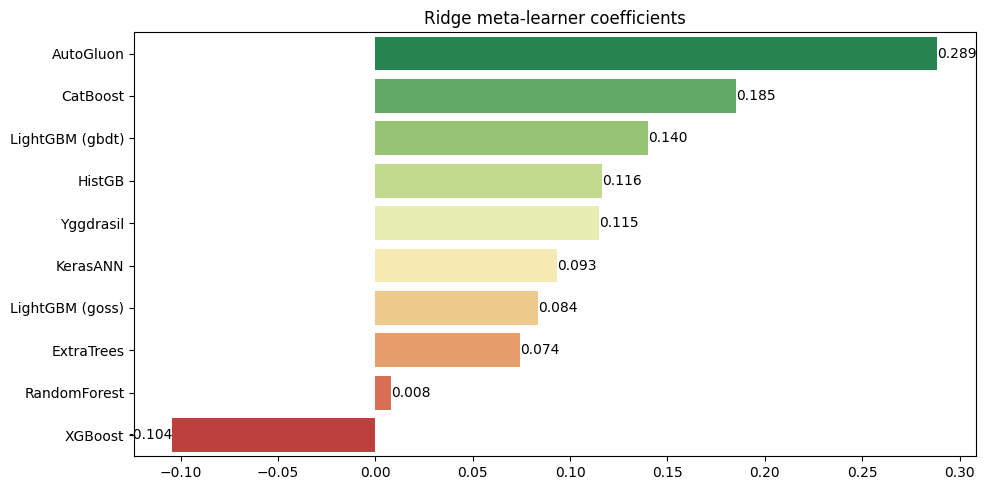

In [144]:
order = np.argsort(ridge_coefs)[::-1]
sorted_coefs = ridge_coefs[order]
sorted_names = np.array(list(oof_preds.keys()))[order]

plt.figure(figsize=(10, len(sorted_names) * 0.5))
ax = sns.barplot(x=sorted_coefs, y=sorted_names, palette="RdYlGn_r")
for i, v in enumerate(sorted_coefs):
    ax.text(v, i, f"{v:.3f}", va="center", ha="left" if v >= 0 else "right")
plt.title("Ridge meta-learner coefficients")
plt.tight_layout()
plt.savefig(FIG_DIR / "ridge_coeffs.png", dpi=150, bbox_inches="tight")
plt.show()

## **Submission**

Back-transformed Ridge predictions written to `Results/submissions/sub_ridge_{RMSLE:.6f}.csv`.  <br> 
The filename records the CV RMSLE for easy tracking across re-runs.

In [145]:
sub = pd.DataFrame({"id": X_test.index, CFG.target: ridge_test_preds})
sub_path = SUB_DIR / f"sub_ridge_{ridge_eval['RMSLE']:.6f}.csv"
sub.to_csv(sub_path, index=False)
print(f"Saved submission to {sub_path}")
print(sub.head())

Saved submission to /content/drive/MyDrive/Predict_Calorie_Expenditure/Results/submissions/sub_ridge_0.059161.csv
       id    Calories
0  750000   27.229403
1  750001  107.863208
2  750002   87.222969
3  750003  125.766870
4  750004   76.057864


## **Results Benchmark**

Per-fold CV scores, mean ± std RMSLE, and calorie-scale RMSE for every model, with the Ridge ensemble highlighted.   <br>
Saved as `Results/tables/model_benchmark.csv` and `Results/figures/model_benchmark.png`; raw fold scores saved as `Results/tables/fold_scores.csv`.

In [146]:
fold_df = pd.DataFrame(scores)
fold_df.to_csv(TAB_DIR / "fold_scores.csv", index=False)

summary_rows = []
for m in fold_df.columns:
    fold_rmsle = fold_df[m].values
    if m == "Ridge (ensemble)":
        eval_d = ridge_eval
    elif m in oof_preds:
        eval_d = evaluate(y.values, oof_preds[m])
    else:
        eval_d = {"RMSLE": float(np.mean(fold_rmsle)), "RMSE_cal": None}
    summary_rows.append(
        {
            "model": m,
            "RMSLE_mean": float(np.mean(fold_rmsle)),
            "RMSLE_std": float(np.std(fold_rmsle)),
            "RMSLE_oof": eval_d["RMSLE"],
            "RMSE_cal": eval_d["RMSE_cal"],
        }
    )
summary = pd.DataFrame(summary_rows).sort_values("RMSLE_mean")
summary.to_csv(TAB_DIR / "model_benchmark.csv", index=False)
print(summary.to_string(index=False))

           model  RMSLE_mean  RMSLE_std  RMSLE_oof  RMSE_cal
Ridge (ensemble)    0.059159   0.000384   0.059161  3.563132
       AutoGluon    0.059403   0.000376   0.059404  3.584647
 LightGBM (gbdt)    0.059754   0.000311   0.059755  3.606102
 LightGBM (goss)    0.059778   0.000361   0.059779  3.595864
        CatBoost    0.059793   0.000334   0.059794  3.642295
          HistGB    0.059890   0.000434   0.059892  3.629338
       Yggdrasil    0.060398   0.000336   0.060399  3.679577
        KerasANN    0.060609   0.000624   0.060612  3.665894
         XGBoost    0.060708   0.000480   0.060710  3.720173
      ExtraTrees    0.061240   0.000556   0.061243  3.706023
    RandomForest    0.061803   0.000643   0.061806  3.738258


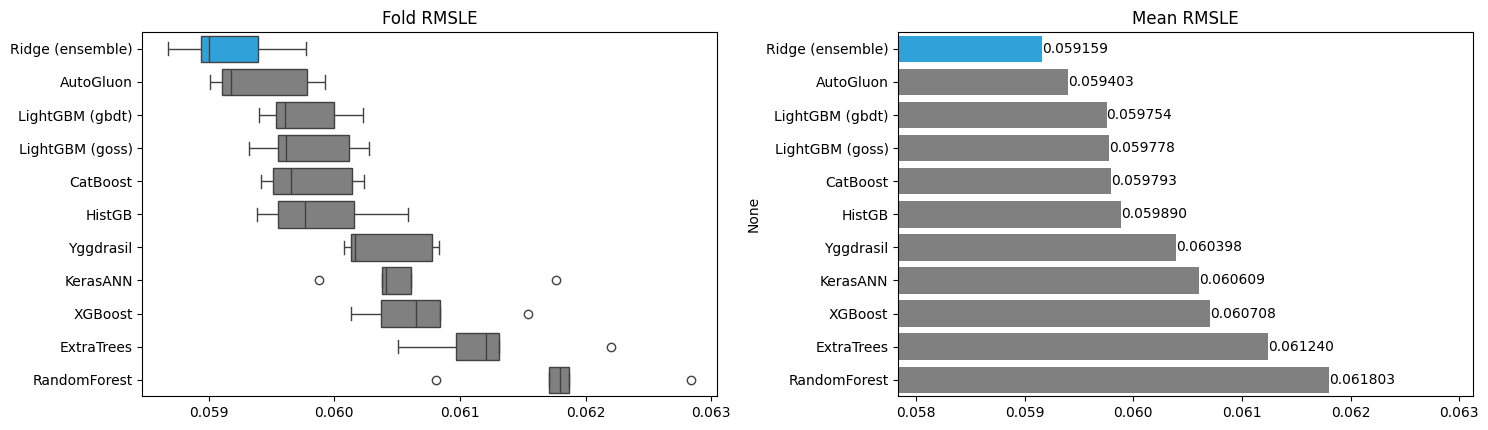

In [147]:
mean_rmsle = fold_df.mean().sort_values()
order_idx = mean_rmsle.index.tolist()
span = mean_rmsle.max() - mean_rmsle.min()
lo = mean_rmsle.min() - span * 0.5
hi = mean_rmsle.max() + span * 0.5

fig, axs = plt.subplots(1, 2, figsize=(15, max(4, fold_df.shape[1] * 0.4)))
box = sns.boxplot(data=fold_df, order=order_idx, ax=axs[0], orient="h", color="grey")
axs[0].set_title("Fold RMSLE")
bar = sns.barplot(x=mean_rmsle.values, y=mean_rmsle.index, ax=axs[1], color="grey")
axs[1].set_title("Mean RMSLE")
axs[1].set_xlim(lo, hi)
for i, (score, model) in enumerate(zip(mean_rmsle.values, mean_rmsle.index)):
    color = "#30a2da" if "ensemble" in model.lower() else "grey"
    bar.patches[i].set_facecolor(color)
    box.patches[i].set_facecolor(color)
    bar.text(score, i, f"{score:.6f}", va="center")
plt.tight_layout()
plt.savefig(FIG_DIR / "model_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()

## **Ablation - Effect of Engineered Features**

The proposal motivates two engineered features: **BMI** and **Duration × Heart_Rate**.  <br>
To quantify their contribution, we train a single fast base model (LightGBM gbdt) on two versions of the same 5-fold CV split:

1. **With engineered features** — the feature set used throughout this notebook.
2. **Without engineered features** — the original 7 columns only.

The comparison is saved to `Results/tables/ablation_features.csv` and `Results/figures/ablation_features.png` and is referenced in the report.

In [148]:
if CFG.run_ablation:
    engineered = ["BMI", "Duration_x_HR"]
    X_nofe = X.drop(columns=engineered)
    X_test_nofe = X_test.drop(columns=engineered)
    X_original_nofe = X_original.drop(columns=engineered)

    lgbm_fit_kwargs = {
        "eval_metric": "rmse",
        "callbacks": [log_evaluation(period=1000), early_stopping(stopping_rounds=100)],
    }

    res_with = train_cv(
        lambda: LGBMRegressor(**lgbm_params),
        X, y, X_test,
        cv=cv,
        name="Ablation_LGBM_with_FE",
        cache_dir=MODEL_DIR,
        extra_X=X_original,
        extra_y=y_original,
        requires_eval_set=True,
        fit_kwargs=lgbm_fit_kwargs,
        force=CFG.force_retrain,
    )
    res_without = train_cv(
        lambda: LGBMRegressor(**lgbm_params),
        X_nofe, y, X_test_nofe,
        cv=cv,
        name="Ablation_LGBM_without_FE",
        cache_dir=MODEL_DIR,
        extra_X=X_original_nofe,
        extra_y=y_original,
        requires_eval_set=True,
        fit_kwargs=lgbm_fit_kwargs,
        force=CFG.force_retrain,
    )

    ablation = pd.DataFrame(
        [
            {
                "variant": "with engineered features",
                "features": X.shape[1],
                "RMSLE_mean": float(np.mean(res_with["fold_scores"])),
                "RMSLE_std": float(np.std(res_with["fold_scores"])),
                "RMSLE_oof": res_with["eval"]["RMSLE"],
                "RMSE_cal": res_with["eval"]["RMSE_cal"],
            },
            {
                "variant": "without engineered features",
                "features": X_nofe.shape[1],
                "RMSLE_mean": float(np.mean(res_without["fold_scores"])),
                "RMSLE_std": float(np.std(res_without["fold_scores"])),
                "RMSLE_oof": res_without["eval"]["RMSLE"],
                "RMSE_cal": res_without["eval"]["RMSE_cal"],
            },
        ]
    )
    delta_rmsle = ablation.loc[0, "RMSLE_oof"] - ablation.loc[1, "RMSLE_oof"]
    delta_rmse_cal = ablation.loc[0, "RMSE_cal"] - ablation.loc[1, "RMSE_cal"]
    ablation.to_csv(TAB_DIR / "ablation_features.csv", index=False)
    print(ablation.to_string(index=False))
    print(f"\nΔ RMSLE (with − without): {delta_rmsle:+.6f}")
    print(f"Δ RMSE(cal) (with − without): {delta_rmse_cal:+.4f}")

[Ablation_LGBM_with_FE] loading from cache: /content/drive/MyDrive/Predict_Calorie_Expenditure/Results/models/Ablation_LGBM_with_FE.pkl
[Ablation_LGBM_without_FE] loading from cache: /content/drive/MyDrive/Predict_Calorie_Expenditure/Results/models/Ablation_LGBM_without_FE.pkl
                    variant  features  RMSLE_mean  RMSLE_std  RMSLE_oof  RMSE_cal
   with engineered features         9    0.059754   0.000311   0.059755  3.606102
without engineered features         7    0.059789   0.000330   0.059790  3.612637

Δ RMSLE (with − without): -0.000034
Δ RMSE(cal) (with − without): -0.0065


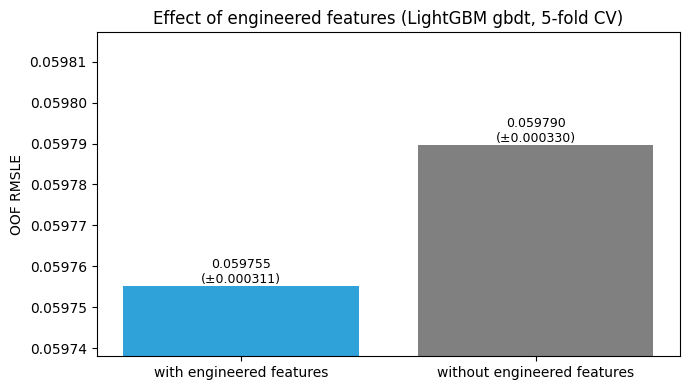

In [149]:
if CFG.run_ablation:
    fig, ax = plt.subplots(figsize=(7, 4))
    colors = ["#30a2da", "grey"]
    bars = ax.bar(ablation["variant"], ablation["RMSLE_oof"], color=colors)
    for b, v, std in zip(bars, ablation["RMSLE_oof"], ablation["RMSLE_std"]):
        ax.text(
            b.get_x() + b.get_width() / 2,
            v,
            f"{v:.6f}\n(±{std:.6f})",
            ha="center",
            va="bottom",
            fontsize=9,
        )
    span = ablation["RMSLE_oof"].max() - ablation["RMSLE_oof"].min()
    ax.set_ylim(
        ablation["RMSLE_oof"].min() - span * 0.5,
        ablation["RMSLE_oof"].max() + span * 0.8,
    )
    ax.set_ylabel("OOF RMSLE")
    ax.set_title("Effect of engineered features (LightGBM gbdt, 5-fold CV)")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "ablation_features.png", dpi=150, bbox_inches="tight")
    plt.show()